In [206]:
import pandas as pd
from sklearn.model_selection import train_test_split
import random
import matplotlib.pyplot as plt
import torchvision.transforms as T
from PIL import Image
import torch
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn
import ast
import Levenshtein

In [207]:
NUM_EPOCHS = 30
TRAIN_DATA = "traindata.csv"
TEST_DATA = "testdata.csv"

In [208]:
train_df = pd.read_csv(TRAIN_DATA)
test_df  = pd.read_csv(TEST_DATA)

In [209]:
full_df = pd.concat([train_df, test_df], ignore_index=True)

In [210]:
full_df.info()
full_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   ImgName      5000 non-null   str  
 1   GroundTruth  5000 non-null   str  
 2   smallLexi    5000 non-null   str  
 3   mediumLexi   5000 non-null   str  
dtypes: str(4)
memory usage: 156.4 KB


,ImgName,GroundTruth,smallLexi,mediumLexi
0,train/1009_2.png,YOU,"['YOU', '1200', '1300', '135', '149', '324', '...","['YOU', '0', '000', '010050', '0123', '019901'..."
1,train/1017_1.png,RESCUE,"['RESCUE', '16', '208', '226', '300', '629', '...","['RESCUE', '0', '0123', '01234', '01922', '06'..."
2,train/1017_2.png,MISSION,"['MISSION', '0', '10234', '123', '1380', '2008...","['MISSION', '0', '000', '01234', '01922', '019..."
3,train/1021_1.png,HOME,"['HOME', '010050', '143KM', '2008', '208', '25...","['HOME', '0', '000', '010050', '01234', '01990..."
4,train/1023_1.png,BORDER,"['BORDER', '12', '143KM', '17', '2003', '2009'...","['BORDER', '0', '000', '010050', '0123', '0123..."


In [211]:
train_df, temp_df = train_test_split(full_df, test_size=0.2, random_state=42)
val_df,   test_df = train_test_split(temp_df, test_size=0.5, random_state=42)
print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

Train: 4000  Val: 500  Test: 500


In [212]:
print(full_df["GroundTruth"].str.len().describe())
MAX_LABEL_LEN = int(full_df["GroundTruth"].str.len().max())
print("Max label length:", MAX_LABEL_LEN)

count    5000.000000
mean        4.989400
std         2.575775
min         1.000000
25%         3.000000
50%         5.000000
75%         6.000000
max        22.000000
Name: GroundTruth, dtype: float64
Max label length: 22


In [213]:
chars = sorted(set("".join(full_df["GroundTruth"].astype(str))))
char_to_idx = {c: i + 1 for i, c in enumerate(chars)}
idx_to_char = {i + 1: c for i, c in enumerate(chars)}
BLANK_IDX   = 0
NUM_CLASSES = len(chars) + 1
print("Vocab size (incl. blank):", NUM_CLASSES)

Vocab size (incl. blank): 37


In [214]:
train_transform = T.Compose([
    T.Resize((32, 256)),
    T.RandomRotation(degrees=(-10, 10), fill=255), # Mild rotations
    T.ColorJitter(brightness=0.3, contrast=0.3),    # Changes lighting/contrast conditions
    T.ToTensor(),
    T.Normalize((0.5,), (0.5,))
])


val_transform = T.Compose([
    T.Resize((32, 256)),
    T.ToTensor(),
    T.Normalize((0.5,), (0.5,))
])

In [215]:
class OCRDataset(Dataset):
    def __init__(self, df, transform):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        image  = Image.open(row["ImgName"]).convert("L")
        image  = self.transform(image)
        text   = row["GroundTruth"]
        target = torch.tensor([char_to_idx[c] for c in text], dtype=torch.long)
        return image, target

In [216]:
def collate_fn(batch):
    images, labels = zip(*batch)
    images         = torch.stack(images)
    target_lengths = torch.tensor([len(x) for x in labels], dtype=torch.long)
    targets        = torch.cat(labels)
    return images, targets, target_lengths

In [217]:
train_ds = OCRDataset(train_df, train_transform)
val_ds   = OCRDataset(val_df,   val_transform)
test_ds  = OCRDataset(test_df,  val_transform)   # FIX 2: test_ds properly created

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, collate_fn=collate_fn)

In [218]:
class CRNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.cnn = nn.Sequential(
            # Layer 1: 32x256 -> 16x128
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Layer 2: 16x128 -> 8x64
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Layer 3: 8x64 -> 8x64
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            
            # Layer 4: 8x64 -> 8x64
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            
            # Squash height from 8 down to 1 while preserving 64 horizontal time steps
            nn.MaxPool2d(kernel_size=(8, 1)) 
        )
        self.rnn = nn.LSTM(
            input_size=256, hidden_size=256,
            num_layers=2, bidirectional=True, batch_first=False,dropout=0.5
        )
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.cnn(x)          # Output shape: (B, 256, 1, 64)
        x = x.squeeze(2)         # Output shape: (B, 256, 64)
        x = x.permute(2, 0, 1)   # Output shape: (64, B, 256) -> Time-first for LSTM
        x, _ = self.rnn(x)       # Output shape: (64, B, 512)
        x = self.fc(x)           # Output shape: (64, B, num_classes)
        return x

In [219]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


model = CRNN(NUM_CLASSES).to(device)


def weights_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

model.apply(weights_init)

criterion = nn.CTCLoss(blank=BLANK_IDX, zero_infinity=True)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)

Using device: cpu


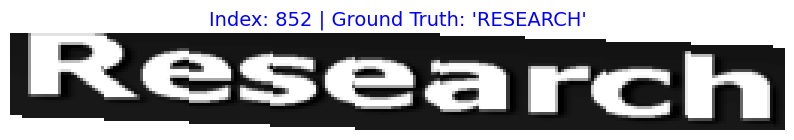

In [220]:
random_idx = random.randint(0, len(train_ds) - 1)
image_tensor, target_tensor = train_ds[random_idx]

ground_truth = "".join([idx_to_char[idx.item()] for idx in target_tensor])

img_numpy = image_tensor.squeeze(0).numpy()  # Remove channel dim -> (32, 256)
img_numpy = img_numpy * 0.5 + 0.5            # Rescale from [-1, 1] back to [0, 1]

plt.figure(figsize=(10, 3))
plt.imshow(img_numpy, cmap='gray')
plt.title(f"Index: {random_idx} | Ground Truth: '{ground_truth}'", fontsize=14, color='blue')
plt.axis('off')
plt.show()

## FIX 3: Training loop (was completely missing)

In [221]:
def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss = 0.0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for images, targets, target_lengths in loader:
            images  = images.to(device)
            targets = targets.to(device)

            logits = model(images)                        # (T, B, C)
            T, B, _ = logits.shape
            log_probs     = logits.log_softmax(2)         # CTC needs log-probs
            input_lengths = torch.full((B,), T, dtype=torch.long)

            loss = criterion(log_probs, targets, input_lengths, target_lengths)

            if training:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer.step()

            total_loss += loss.item()
    return total_loss / len(loader)


for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = run_epoch(train_loader, training=True)
    val_loss   = run_epoch(val_loader,   training=False)
    print(f"Epoch {epoch:>2}/{NUM_EPOCHS}  train={train_loss:.4f}  val={val_loss:.4f}")

torch.save(model.state_dict(), "crnn_trained.pth")
print("Model saved.")

Epoch  1/30  train=4.8468  val=3.6152
Epoch  2/30  train=3.5675  val=3.5060
Epoch  3/30  train=3.4621  val=3.4079
Epoch  4/30  train=3.3418  val=3.2468
Epoch  5/30  train=3.2474  val=3.1474
Epoch  6/30  train=3.1320  val=3.0117
Epoch  7/30  train=3.0185  val=2.9727
Epoch  8/30  train=2.8651  val=2.6967
Epoch  9/30  train=2.6545  val=2.4085
Epoch 10/30  train=2.3433  val=2.1694
Epoch 11/30  train=1.9542  val=1.7178
Epoch 12/30  train=1.6784  val=1.4646
Epoch 13/30  train=1.4639  val=1.2572
Epoch 14/30  train=1.2613  val=1.1067
Epoch 15/30  train=1.1513  val=1.0049
Epoch 16/30  train=1.0318  val=0.8691
Epoch 17/30  train=0.9419  val=0.8788
Epoch 18/30  train=0.8752  val=0.8255
Epoch 19/30  train=0.8023  val=0.7893
Epoch 20/30  train=0.7642  val=0.7494
Epoch 21/30  train=0.7172  val=0.7327
Epoch 22/30  train=0.6818  val=0.6587
Epoch 23/30  train=0.6307  val=0.6607
Epoch 24/30  train=0.5981  val=0.6505
Epoch 25/30  train=0.5814  val=0.6301
Epoch 26/30  train=0.5455  val=0.6845
Epoch 27/30 

In [222]:
def decode_single(pred_sequence):
    """Greedy CTC decode for a 1-D array of class indices."""
    output, prev = [], -1
    for p in pred_sequence:
        if p != prev and p != BLANK_IDX:
            output.append(idx_to_char[p])
        prev = p
    return "".join(output)

def decode_batch(logits):
    """
    logits: (T, B, num_classes)
    returns: list of decoded strings, one per sample
    """
    pred = logits.argmax(2).cpu().numpy()   # (T, B)
    return [decode_single(pred[:, b]) for b in range(pred.shape[1])]

In [223]:
def predict_image(path):
    image = Image.open(path).convert("L")
    image = val_transform(image).unsqueeze(0).to(device)  # (1, 1, 32, 256)
    model.eval()
    with torch.no_grad():
        logits = model(image)       # (T, 1, num_classes)
    return decode_batch(logits)[0]  # single string

In [224]:
def edit_distance_correction(pred_str, lexicon_list_str):
    try:
        lexicon = ast.literal_eval(lexicon_list_str)
    except:
        return pred_str
        
    if not lexicon or len(pred_str) == 0:
        return pred_str

    best_match = pred_str
    min_dist = float('inf')
    
    for word in lexicon:
        word_clean = word.upper().strip()
        dist = Levenshtein.distance(pred_str.upper(), word_clean)
        if dist < min_dist:
            min_dist = dist
            best_match = word_clean
            
    return best_match

In [227]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CRNN(num_classes=NUM_CLASSES)
model_path = "crnn_trained.pth"
state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)
model = model.to(device)
model.eval()

print(f"Successfully loaded weights from '{model_path}' onto {device}!")

Successfully loaded weights from 'crnn_trained.pth' onto cpu!


In [228]:
correct_raw = 0
correct_lexicon = 0
total = 0

model.eval()
with torch.no_grad():

    for idx in range(len(test_ds)):
        image_tensor, target_tensor = test_ds[idx]
        
        gt_str = "".join([idx_to_char[i.item()] for i in target_tensor])
        
        input_tensor = image_tensor.unsqueeze(0).to(device)  # Shape: (1, 1, 32, 256)
        logits = model(input_tensor)
        pred_raw = decode_batch(logits)[0]
        
        lexicon_str = test_df.iloc[idx]['smallLexi']
        
        pred_corrected = edit_distance_correction(pred_raw, lexicon_str)
        
        correct_raw += int(pred_raw == gt_str)
        correct_lexicon += int(pred_corrected == gt_str)
        total += 1

print(f"Total Evaluated Words: {total}")
print(f"Raw Model Word Accuracy: {correct_raw}/{total} = {100*correct_raw/total:.2f}%")
print(f"Lexicon-Corrected Word Accuracy: {correct_lexicon}/{total} = {100*correct_lexicon/total:.2f}%")

Total Evaluated Words: 500
Raw Model Word Accuracy: 304/500 = 60.80%
Lexicon-Corrected Word Accuracy: 476/500 = 95.20%


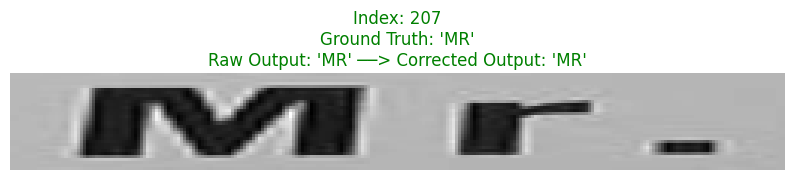

In [230]:
random_idx = random.randint(0, len(test_ds) - 1)
image_tensor, target_tensor = test_ds[random_idx]

ground_truth = "".join([idx_to_char[idx.item()] for idx in target_tensor])

model.eval()
with torch.no_grad():
    input_tensor = image_tensor.unsqueeze(0).to(device)
    logits = model(input_tensor)
    predicted_raw = decode_batch(logits)[0]

lexicon_str = test_df.iloc[random_idx]['smallLexi']
predicted_corrected = edit_distance_correction(predicted_raw, lexicon_str)

img_numpy = image_tensor.squeeze(0).numpy()
img_numpy = img_numpy * 0.5 + 0.5

plt.figure(figsize=(10, 3.5))
plt.imshow(img_numpy, cmap='gray')

title_color = 'green' if predicted_corrected == ground_truth else 'red'

plt.title(
    f"Index: {random_idx}\n"
    f"Ground Truth: '{ground_truth}'\n"
    f"Raw Output: '{predicted_raw}' ──> Corrected Output: '{predicted_corrected}'", 
    fontsize=12, 
    color=title_color
)

plt.axis('off')
plt.show()